In [1]:
import os, re, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

SEED = 42
WORK = "/kaggle/working"          # outputs and caches are saved here

# Find the competition folder automatically
TRAIN_CSV = glob.glob("/kaggle/input/**/train.csv", recursive=True)[0]
DATA_DIR = os.path.dirname(TRAIN_CSV)
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")   # its 'label' column is a dummy (-1), never used
print("train:", train.shape, "| test:", test.shape)

# The same file names (e.g. audio_192.wav) appear in both train.csv and test.csv,
# so index the audio separately for each split folder. Never match by name alone.
all_wavs = glob.glob(f"{DATA_DIR}/**/*.wav", recursive=True)
def index_for(split):
    sel = [p for p in all_wavs if split in os.path.relpath(p, DATA_DIR).lower()]
    return {os.path.basename(p): p for p in sel}

train_idx, test_idx = index_for("train"), index_for("test")
if not train_idx or not test_idx:            # fallback if there are no train/test sub-folders
    flat = {os.path.basename(p): p for p in all_wavs}
    train_idx, test_idx = train_idx or flat, test_idx or flat

train["path"] = train.filename.map(train_idx)
test["path"] = test.filename.map(test_idx)
print("missing train audio:", train.path.isna().sum(), "| missing test audio:", test.path.isna().sum())
assert train.path.notna().all() and test.path.notna().all(), "Some audio files were not found"
y = train.label.values

import torch
print("GPU available:", torch.cuda.is_available())

train: (769, 2) | test: (216, 2)
missing train audio: 0 | missing test audio: 0
GPU available: True


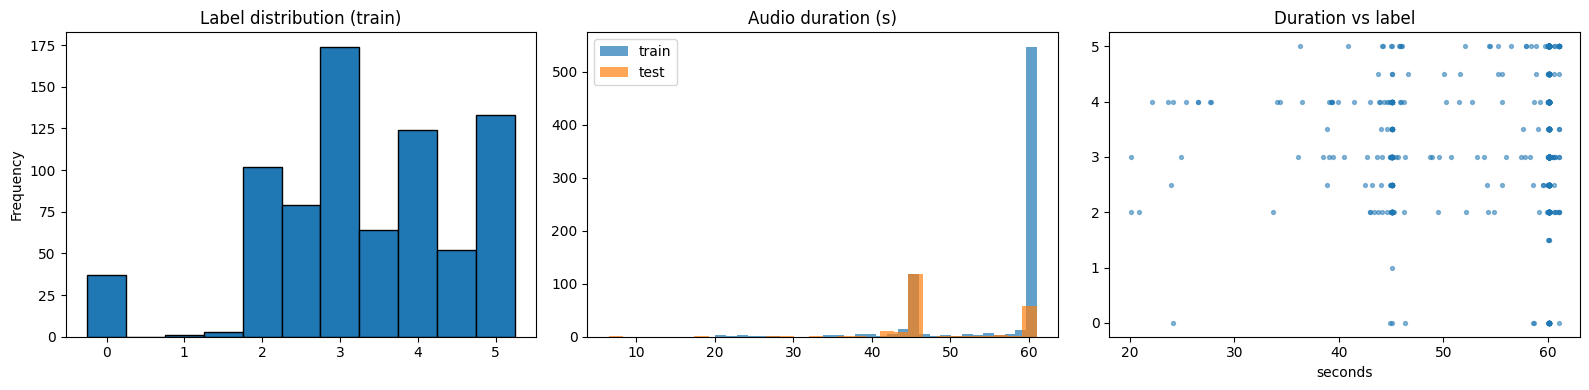

Baseline RMSE (always predict mean): 1.2382
Clips with label 0: 37


In [2]:
import soundfile as sf
train["duration"] = [sf.info(p).duration for p in train.path]
test["duration"] = [sf.info(p).duration for p in test.path]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
train.label.plot.hist(bins=np.arange(-0.25, 5.5, 0.5), ax=ax[0], edgecolor="k")
ax[0].set_title("Label distribution (train)")
ax[1].hist(train.duration, bins=30, alpha=.7, label="train")
ax[1].hist(test.duration, bins=30, alpha=.7, label="test")
ax[1].set_title("Audio duration (s)"); ax[1].legend()
ax[2].scatter(train.duration, train.label, s=8, alpha=.5)
ax[2].set_title("Duration vs label"); ax[2].set_xlabel("seconds")
plt.tight_layout(); plt.show()

print("Baseline RMSE (always predict mean):", round(float(np.sqrt(np.mean((y - y.mean())**2))), 4))
print("Clips with label 0:", int((y == 0).sum()))

In [3]:
import os, torch, librosa
import pandas as pd
from tqdm.auto import tqdm
from transformers import pipeline

use_gpu = torch.cuda.is_available()
WHISPER_ID = "openai/whisper-small" if use_gpu else "openai/whisper-tiny"
BATCH = 8 if use_gpu else 4
print("device:", "cuda" if use_gpu else "cpu", "| model:", WHISPER_ID)

MAX_SEC = 45   # train clips are mostly 60 s, test mostly 45 s, so crop all to 45 s
def load_audio(path, sr=16000):
    y_, _ = librosa.load(path, sr=sr, mono=True, duration=MAX_SEC)
    return y_

def transcribe_all(paths):
    asr = pipeline("automatic-speech-recognition", model=WHISPER_ID,
                   device=0 if use_gpu else -1,
                   torch_dtype=torch.float16 if use_gpu else torch.float32,
                   chunk_length_s=30, batch_size=BATCH)
    out = []
    for i in tqdm(range(0, len(paths), BATCH), desc="Whisper"):
        wavs = [load_audio(p) for p in paths[i:i + BATCH]]
        res = asr([{"raw": w, "sampling_rate": 16000} for w in wavs],
                  generate_kwargs={"language": "en", "task": "transcribe"})
        out += [r["text"].strip() for r in res]
    return out

TR_TXT, TE_TXT = f"{WORK}/train_text.csv", f"{WORK}/test_text.csv"
if os.path.exists(TR_TXT) and os.path.exists(TE_TXT):      # cached from an earlier run
    print("Using cached transcripts")
    train["text"] = pd.read_csv(TR_TXT).text.fillna("").values
    test["text"] = pd.read_csv(TE_TXT).text.fillna("").values
else:
    train["text"] = transcribe_all(train.path.tolist())
    test["text"] = transcribe_all(test.path.tolist())
    train[["filename", "label", "text"]].to_csv(TR_TXT, index=False)
    test[["filename", "text"]].to_csv(TE_TXT, index=False)

train[["filename", "label", "text"]].head()

device: cuda | model: openai/whisper-small


config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  967MB            

model.safetensors: downloading bytes:           |  0.00B            

...

[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


Whisper:   0%|          | 0/27 [00:00<?, ?it/s]

,filename,label,text
0,audio_192.wav,3.0,"The playground is very, very beautiful and fun..."
1,audio_436.wav,3.0,The scene of a school playground. Our playgrou...
2,audio_447.wav,3.5,My favorite place to visit is the beach. I lov...
3,audio_126.wav,2.0,"Once upon a time, we, with five friends, went ..."
4,audio_61.wav,2.0,"Well, when I was a child, I remember I went to..."


In [4]:
import numpy as np
from transformers import WhisperFeatureExtractor, WhisperModel

dev = "cuda" if torch.cuda.is_available() else "cpu"
fe = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")
encoder = WhisperModel.from_pretrained("openai/whisper-small").get_encoder().to(dev).eval()

def waveform_feats(w, sr=16000):
    # Speech/pause statistics from energy-based silence detection
    dur = len(w) / sr
    iv = librosa.effects.split(w, top_db=30)                    # non-silent intervals
    if len(iv) == 0:
        return dict(duration=dur, speech_ratio=0, n_pauses=0, mean_pause=0, max_pause=0,
                    pauses_per_min=0, rms_mean=0, rms_std=0)
    speech = sum(e - s for s, e in iv) / sr
    gaps = [(iv[i + 1][0] - iv[i][1]) / sr for i in range(len(iv) - 1)]
    pauses = [g for g in gaps if g > 0.3]                       # pauses longer than 0.3 s
    rms = librosa.feature.rms(y=w)[0]
    return dict(duration=dur, speech_ratio=speech / dur, n_pauses=len(pauses),
                mean_pause=float(np.mean(pauses)) if pauses else 0.0,
                max_pause=max(gaps) if gaps else 0.0, pauses_per_min=len(pauses) / dur * 60,
                rms_mean=float(rms.mean()), rms_std=float(rms.std()))

def whisper_embed(w):
    # Whisper's encoder sees 30 s windows, so split into 30 s chunks and pool only real-audio frames
    chunks = [w[i:i + 480000] for i in range(0, len(w), 480000)]
    chunks = [c for c in chunks if len(c) > 16000] or [w]
    vecs = []
    for c in chunks:
        x = fe(c, sampling_rate=16000, return_tensors="pt").input_features.to(dev)
        with torch.no_grad():
            h = encoder(x).last_hidden_state[0]                 # (1500, 768)
        h = h[:max(int(len(c) / 480000 * 1500), 2)]
        vecs.append(torch.cat([h.mean(0), h.std(0)]).float().cpu().numpy())
    return np.mean(vecs, axis=0)

def audio_pass(paths, tag):
    f_csv, e_npy = f"{WORK}/{tag}_wave.csv", f"{WORK}/{tag}_audio_emb.npy"
    if os.path.exists(f_csv) and os.path.exists(e_npy):          # cached
        return pd.read_csv(f_csv), np.load(e_npy)
    feats, embs = [], []
    for p in tqdm(paths, desc=f"audio {tag}"):
        w = load_audio(p)
        feats.append(waveform_feats(w)); embs.append(whisper_embed(w))
    F, E = pd.DataFrame(feats), np.vstack(embs)
    F.to_csv(f_csv, index=False); np.save(e_npy, E)
    return F, E

wave_tr, A_tr = audio_pass(train.path.tolist(), "train")
wave_te, A_te = audio_pass(test.path.tolist(), "test")
print("audio embedding shape:", A_tr.shape, A_te.shape)
print("speech_ratio for label-0 clips (mean):", wave_tr.speech_ratio[y == 0].mean().round(3),
      "vs other clips:", wave_tr.speech_ratio[y > 0].mean().round(3))

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

audio train:   0%|          | 0/769 [00:00<?, ?it/s]

audio test:   0%|          | 0/216 [00:00<?, ?it/s]

audio embedding shape: (769, 1536) (216, 1536)
speech_ratio for label-0 clips (mean): 1.0 vs other clips: 0.713


In [5]:
import re
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer

# Quick look: what do the label-0 clips contain?
print(train.loc[train.label == 0, "text"].head(5).tolist())

# --- GPT-2: grammatical text is more predictable, so lower NLL ~ fewer errors ---
tok = AutoTokenizer.from_pretrained("gpt2")
lm = AutoModelForCausalLM.from_pretrained("gpt2").to(dev).eval()

def nll(text):
    ids = tok(text, return_tensors="pt", truncation=True, max_length=1024).input_ids.to(dev)
    if ids.shape[1] < 2: return np.nan
    with torch.no_grad():
        return lm(ids, labels=ids).loss.item()

FILLERS = {"um", "uh", "umm", "uhh", "er", "erm", "hmm", "ah"}
SUBORD = {"because", "although", "though", "which", "that", "when", "while", "if", "unless",
          "since", "whereas", "whom", "whose", "where", "after", "before", "so"}
tokens = lambda s: re.findall(r"[A-Za-z']+", s.lower())

def text_feats(text):
    words = tokens(text)
    sents = [s for s in re.split(r"(?<=[.!?])\s+", text.strip()) if s]
    sl = np.array([len(tokens(s)) for s in sents]) if sents else np.array([0])
    n = max(len(words), 1)
    repeats = sum(1 for a, b in zip(words, words[1:]) if a == b)           # "I I went"
    sent_nll = [nll(s) for s in sents if len(tokens(s)) >= 3]
    sent_nll = [v for v in sent_nll if not np.isnan(v)]
    return dict(n_words=len(words), n_sents=len(sents), avg_sent_len=sl.mean(), max_sent_len=sl.max(),
                std_sent_len=sl.std(), short_sent_ratio=float((sl <= 4).mean()),
                ttr=len(set(words)) / n, filler_ratio=sum(w in FILLERS for w in words) / n,
                repeat_ratio=repeats / n, long_word_ratio=sum(len(w) >= 7 for w in words) / n,
                subord_ratio=sum(w in SUBORD for w in words) / n,
                commas_per_sent=text.count(",") / max(len(sents), 1),
                ends_with_punct=float(text.strip()[-1:] in ".!?"),
                lm_nll=nll(text) if text.strip() else np.nan,
                lm_nll_max_sent=max(sent_nll) if sent_nll else np.nan,
                lm_nll_mean_sent=float(np.mean(sent_nll)) if sent_nll else np.nan)

def build_hand(df, wave):
    T = pd.DataFrame([text_feats(t) for t in tqdm(df.text, desc="text feats")])
    H = pd.concat([wave.reset_index(drop=True), T], axis=1)
    H["words_per_sec"] = H.n_words / H.duration                     # speaking rate
    H["words_per_speech_sec"] = H.n_words / (H.duration * H.speech_ratio).clip(lower=1)
    return H

H_tr, H_te = build_hand(train, wave_tr), build_hand(test, wave_te)
med = H_tr.median()                                                  # impute NaN with train medians
H_tr, H_te = H_tr.fillna(med), H_te.fillna(med)
print("hand-made feature matrix:", H_tr.shape, H_te.shape)

# --- Sentence-transformer text embedding ---
st = SentenceTransformer("all-mpnet-base-v2", device=dev)
T_tr = st.encode(train.text.tolist(), batch_size=32, normalize_embeddings=True, show_progress_bar=True)
T_te = st.encode(test.text.tolist(), batch_size=32, normalize_embeddings=True, show_progress_bar=True)
print("text embedding shape:", T_tr.shape, T_te.shape)

# Save everything so a session restart doesn't cost recomputation
H_tr.to_csv(f"{WORK}/H_tr.csv", index=False); H_te.to_csv(f"{WORK}/H_te.csv", index=False)
np.save(f"{WORK}/T_tr.npy", T_tr); np.save(f"{WORK}/T_te.npy", T_te)
H_tr.head(3)

['well pedaling, the wind is off on my screen, so that I try to stay safe all day long. Every time I leave my phone, I think, make myself forget the truth', "It's a wonderful doing here because we are living at the same house but we don't talk to each other. I don't know that we live together but I extremely love my brother and the day we live together it is wonderful and happiest today in my life. I don't know whether to talk to him or not.", 'So it has to do with the, you know, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, 

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

text embedding shape: (769, 768) (216, 768)


,duration,speech_ratio,n_pauses,mean_pause,max_pause,pauses_per_min,rms_mean,rms_std,n_words,n_sents,...,repeat_ratio,long_word_ratio,subord_ratio,commas_per_sent,ends_with_punct,lm_nll,lm_nll_max_sent,lm_nll_mean_sent,words_per_sec,words_per_speech_sec
0,45.0,0.534756,14,0.941714,2.400,18.666667,0.026978,0.035026,63,4,...,0.015873,0.095238,0.015873,1.500000,1.0,3.697471,6.281743,4.449838,1.400000,2.618019
1,45.0,0.850667,3,0.757333,1.408,4.000000,0.067750,0.059115,86,6,...,0.000000,0.151163,0.023256,0.166667,0.0,4.612778,6.028967,5.207878,1.911111,2.246604
2,45.0,0.794489,12,0.557333,0.800,16.000000,0.058276,0.051541,112,9,...,0.000000,0.133929,0.017857,0.333333,0.0,2.579324,4.749822,3.706463,2.488889,3.132692


In [6]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.base import clone
from scipy.stats import pearsonr

rmse = lambda a, b: float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

FEATURES = {                                   # name -> (train matrix, test matrix)
    "audio": (A_tr, A_te),
    "text":  (T_tr, T_te),
    "hand":  (H_tr.values, H_te.values),
}
BASE_MODELS = {                                # name -> (model, feature family)
    "audioEmb_SVR":  (make_pipeline(StandardScaler(), PCA(128, random_state=SEED), SVR(C=3, epsilon=0.1)), "audio"),
    "textEmb_Ridge": (RidgeCV(alphas=np.logspace(-1, 3, 20)), "text"),
    "hand_ExtraTrees": (ExtraTreesRegressor(500, min_samples_leaf=2, random_state=SEED, n_jobs=-1), "hand"),
    "hand_HistGB":   (HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=4, random_state=SEED), "hand"),
}

kf = KFold(5, shuffle=True, random_state=SEED)
oof = np.zeros((len(y), len(BASE_MODELS)))
test_base = np.zeros((len(test), len(BASE_MODELS)))
train_base = np.zeros((len(y), len(BASE_MODELS)))      # full-fit predictions, only for the "train RMSE" report

for j, (name, (model, fam)) in enumerate(BASE_MODELS.items()):
    X, T = FEATURES[fam]
    for tr, va in kf.split(X):
        m = clone(model).fit(X[tr], y[tr])
        oof[va, j] = m.predict(X[va])
        test_base[:, j] += m.predict(T) / kf.get_n_splits()
    full = clone(model).fit(X, y)
    train_base[:, j] = full.predict(X)
    print(f"{name:18s} CV RMSE = {rmse(oof[:, j], y):.4f} | CV Pearson = {pearsonr(oof[:, j], y)[0]:.4f}")

# Meta-model: non-negative linear blend of the base predictions
meta = LinearRegression(positive=True)
stack_cv = np.clip(cross_val_predict(meta, oof, y, cv=KFold(5, shuffle=True, random_state=7)), 0, 5)
meta.fit(oof, y)
stack_train = np.clip(meta.predict(train_base), 0, 5)
final_test = np.clip(meta.predict(test_base), 0, 5)

print("\nStack weights:", dict(zip(BASE_MODELS, meta.coef_.round(3))), "| intercept:", round(meta.intercept_, 3))
print("=" * 55)
print(f"TRAINING RMSE (optimistic, models refit on all data): {rmse(stack_train, y):.4f}")
print(f"CV RMSE  (honest estimate, 5-fold OOF)               : {rmse(stack_cv, y):.4f}")
print(f"CV Pearson                                           : {pearsonr(stack_cv, y)[0]:.4f}")
print(f"Baseline RMSE (predict mean)                         : {rmse(np.full_like(y, y.mean()), y):.4f}")
print("=" * 55)

audioEmb_SVR       CV RMSE = 0.6317 | CV Pearson = 0.8660
textEmb_Ridge      CV RMSE = 1.0278 | CV Pearson = 0.5577
hand_ExtraTrees    CV RMSE = 0.7888 | CV Pearson = 0.7728
hand_HistGB        CV RMSE = 0.8237 | CV Pearson = 0.7495

Stack weights: {'audioEmb_SVR': np.float64(0.692), 'textEmb_Ridge': np.float64(0.125), 'hand_ExtraTrees': np.float64(0.216), 'hand_HistGB': np.float64(0.094)} | intercept: -0.494
TRAINING RMSE (optimistic, models refit on all data): 0.1370
CV RMSE  (honest estimate, 5-fold OOF)               : 0.5889
CV Pearson                                           : 0.8801
Baseline RMSE (predict mean)                         : 1.2382


In [7]:
sub = pd.DataFrame({"filename": test.filename, "label": final_test})
sub.to_csv(f"{WORK}/submission.csv", index=False)
print(sub.shape, "| prediction range:", round(float(sub.label.min()), 2), "to", round(float(sub.label.max()), 2))

ss = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")
print("sample_submission rows:", len(ss), "| our rows:", len(sub))
print("filenames in sample_submission but not in our file:", len(set(ss.filename) - set(sub.filename)))
sub.head()

(216, 2) | prediction range: 1.51 to 5.0
sample_submission rows: 204 | our rows: 216
filenames in sample_submission but not in our file: 179


,filename,label
0,audio_128.wav,3.095874
1,audio_156.wav,4.065730
2,audio_19.wav,4.862915
3,audio_108.wav,2.384268
4,audio_206.wav,2.230200
